In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, mean_squared_error,
                             mean_absolute_error, r2_score, confusion_matrix,
                             classification_report)

from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from xgboost         import XGBRegressor,XGBClassifier
from lightgbm        import LGBMRegressor,LGBMClassifier
from catboost        import CatBoostClassifier, CatBoostRegressor
from sklearn.preprocessing import OneHotEncoder


import time
import psutil
import os
import warnings
from datetime import datetime
import json


import kagglehub
import tracemalloc


# Reqression

In [9]:
path_ff = kagglehub.dataset_download("elikplim/forest-fires-data-set")

# Qovluqdakı CSV faylı tap
files = os.listdir(path_ff)
csv_path = os.path.join(path_ff, files[0])  # adətən tək csv olur
df = pd.read_csv(csv_path)

df = pd.get_dummies(df, columns=["month", "day"], drop_first=True)
df["area"] = np.log1p(df["area"])
X = df.drop("area", axis=1)
y = df["area"]

X_train_, X_test_, y_train_, y_test_ = train_test_split(
    X, y, test_size=0.2, random_state=42
)


def train_evaluate(model, X_train_, y_train_, X_test_, y_test_, name):
    tracemalloc.start()
    
    start_train = time.time()
    model.fit(X_train_, y_train_)
    train_time = time.time() - start_train
    
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    memory_mb = peak / 10**6  # MB
    
    start_pred = time.time()
    preds = model.predict(X_test_)
    pred_time = time.time() - start_pred
    
    mse = mean_squared_error(y_test_, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_, preds)
    r2 = r2_score(y_test_, preds)
    
    return [name, mse, rmse, mae, r2, train_time, pred_time, memory_mb]


ada = AdaBoostRegressor(random_state=42)
res_ada = train_evaluate(ada, X_train_, y_train_, X_test_, y_test_, "AdaBoost")


xgb = XGBRegressor(random_state=42, verbosity=0)
res_xgb = train_evaluate(xgb, X_train_, y_train_, X_test_, y_test_, "XGBoost")


lgb = LGBMRegressor(random_state=42)
res_lgb = train_evaluate(lgb, X_train_, y_train_, X_test_, y_test_, "LightGBM")

cat = CatBoostRegressor(verbose=0, random_state=42)
res_cat = train_evaluate(cat, X_train_, y_train_, X_test_, y_test_, "CatBoost")

results = pd.DataFrame(
    [res_ada, res_xgb, res_lgb, res_cat],
    columns=[
        "Model",
        "MSE",
        "RMSE",
        "MAE",
        "R2",
        "Train Time (s)",
        "Predict Time (s)",
        "Peak Memory (MB)"
    ]
)

results.sort_values("RMSE")


,Model,MSE,RMSE,MAE,R2,Train Time (s),Predict Time (s),Peak Memory (MB)
2,LightGBM,2.460188,1.568499,1.258757,-0.119355,0.048223,0.001373,1.373933
3,CatBoost,2.475767,1.573457,1.221832,-0.126443,1.207959,0.001730,0.076375
0,AdaBoost,2.536901,1.592765,1.385206,-0.154259,0.166919,0.002220,0.280644
1,XGBoost,2.917604,1.708100,1.313125,-0.327474,0.145278,0.005287,0.109691


# •	Performance comparison bar charts

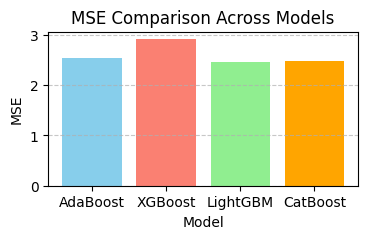

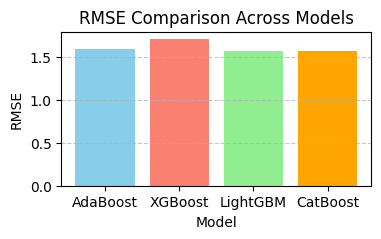

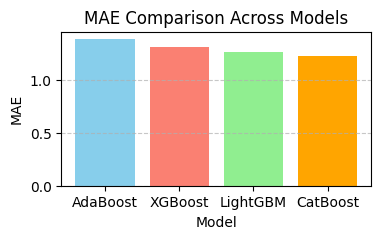

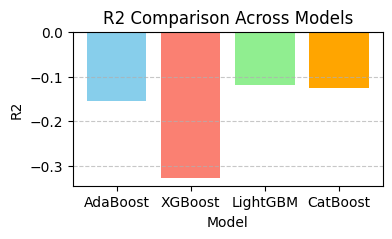

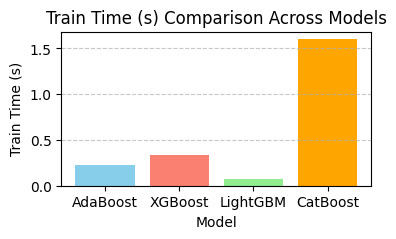

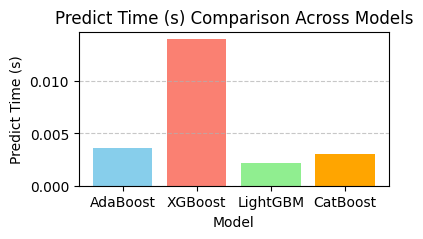

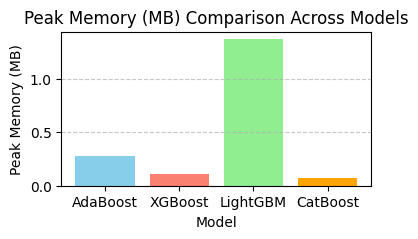

In [9]:
import matplotlib.pyplot as plt

# Performans metrikləri üçün sütunlar
metrics = ["MSE", "RMSE", "MAE", "R2", "Train Time (s)", "Predict Time (s)", "Peak Memory (MB)"]

# Hər metric üçün ayrı bar chart
for metric in metrics:
    plt.figure(figsize=(4, 2))
    plt.bar(results["Model"], results[metric], color=['skyblue', 'salmon', 'lightgreen', 'orange'])
    plt.title(f"{metric} Comparison Across Models")
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


# •	Learning curves

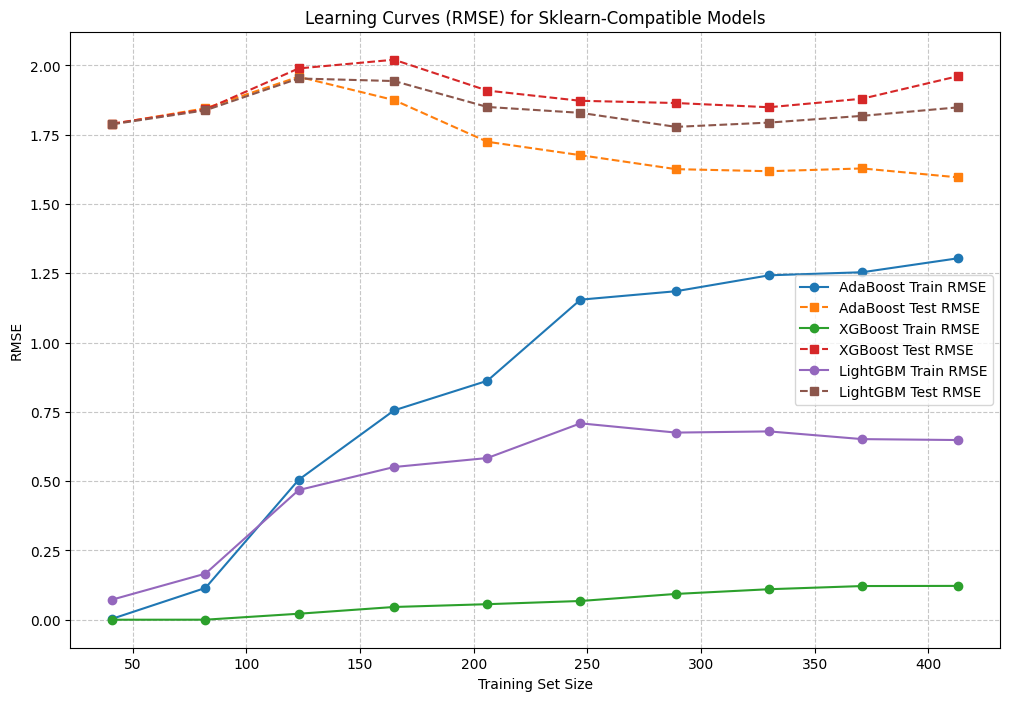

In [10]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# CatBoost-u çıxırıq
models = {
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    "LightGBM": LGBMRegressor(random_state=42)
}

plt.figure(figsize=(12, 8))

for name, model in models.items():
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y,
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='neg_mean_squared_error',  
        n_jobs=-1
    )
    
    train_rmse = np.sqrt(-train_scores.mean(axis=1))
    test_rmse = np.sqrt(-test_scores.mean(axis=1))
    
    plt.plot(train_sizes, train_rmse, 'o-', label=f"{name} Train RMSE")
    plt.plot(train_sizes, test_rmse, 's--', label=f"{name} Test RMSE")

plt.title("Learning Curves (RMSE) for Sklearn-Compatible Models")
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)



# •	Feature importance plots

In [11]:
import numpy as np
import pandas as pd

models = {
    "AdaBoost": ada,
    "XGBoost": xgb,
    "LightGBM": lgb,
    "CatBoost": cat
}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"{name} FEATURE IMPORTANCE")
    print(f"{'='*60}")
    
    # Feature importance əldə edirik
    if name == "CatBoost":
        importances = model.get_feature_importance()
    else:
        importances = model.feature_importances_
    
    # Feature adları
    features = np.array(X.columns)
    
    # Böyükdən kiçiyə sıralama
    indices = np.argsort(importances)[::-1]
    sorted_features = features[indices]
    sorted_importances = importances[indices]
    
    # DataFrame cədvəli
    df = pd.DataFrame({
        "Rank": range(1, len(sorted_features) + 1),
        "Feature": sorted_features,
        "Importance": sorted_importances
    })
    
    print(df.to_string(index=False))



AdaBoost FEATURE IMPORTANCE
 Rank   Feature  Importance
    1       DMC    0.226645
    2      temp    0.147336
    3        RH    0.125389
    4       ISI    0.107321
    5         Y    0.089414
    6         X    0.066127
    7      wind    0.065082
    8        DC    0.056391
    9      FFMC    0.037812
   10   day_thu    0.031616
   11   day_sat    0.019260
   12 month_aug    0.011951
   13 month_dec    0.008125
   14 month_jul    0.004556
   15 month_may    0.002875
   16   day_wed    0.000100
   17   day_sun    0.000000
   18   day_tue    0.000000
   19   day_mon    0.000000
   20 month_mar    0.000000
   21 month_nov    0.000000
   22 month_oct    0.000000
   23 month_sep    0.000000
   24      rain    0.000000
   25 month_jun    0.000000
   26 month_jan    0.000000
   27 month_feb    0.000000

XGBoost FEATURE IMPORTANCE
 Rank   Feature  Importance
    1 month_dec    0.305189
    2 month_feb    0.101682
    3 month_may    0.075859
    4   day_sat    0.063910
    5   day_wed    

# Classification

In [ ]:


# Kagglehub-dan yüklə
try:
    import kagglehub
    path_car = kagglehub.dataset_download("elikplim/car-evaluation-data-set")
    # İlk CSV dosyasını bul
    files = [f for f in os.listdir(path_car) if f.endswith('.data') or f.endswith('.csv')]
    csv_path = os.path.join(path_car, files[0]) if files else None
    if csv_path is None:
        raise FileNotFoundError("CSV dosyası bulunamadı")
except Exception as e:
    print(f"Kagglehub ile yükleme başarısız: {e}. Alternatif yükleme yöntemi kullanılıyor.")
    csv_path = "car.data"

# Sütun adlarını təyin et
cols = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
df_car = pd.read_csv(csv_path, names=cols)

# Hamısını category tipinə çevir
for col in df_car.columns:
    df_car[col] = df_car[col].astype("category")

print("Veri seti bilgileri:")
print(f"Toplam örnek: {len(df_car)}")
print(f"Sınıf dağılımı:\n{df_car['class'].value_counts()}")
print(f"Sınıf sayısı: {len(df_car['class'].unique())}")

# Özellikler ve hedef değişken
X_car = df_car.drop("class", axis=1)
y_car = df_car["class"]

# HEDEF DEĞİŞKENİ KODLAMA
le = LabelEncoder()
y_car_encoded = le.fit_transform(y_car)
print(f"\nSınıf kodlaması: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Train-test ayırma
X_train_car, X_test_car, y_train, y_test = train_test_split(
    X_car, y_car_encoded, test_size=0.2, random_state=42, stratify=y_car_encoded
)

# OneHotEncoder (CatBoost hariç diğer modeller için)
ohe = OneHotEncoder(drop="first", sparse_output=False)
X_train_enc = ohe.fit_transform(X_train_car)
X_test_enc = ohe.transform(X_test_car)

def train_evaluate_class(model, X_train, y_train, X_test, y_test, name, model_type="standard"):
    """
    Modeli eğitir ve değerlendirir.
    """
    tracemalloc.start()
    
    try:
        # Eğitim süresi
        start_train = time.time()
        
        if model_type == "catboost":
            model.fit(X_train, y_train, verbose=0)
        else:
            model.fit(X_train, y_train)
            
        train_time = time.time() - start_train
        
        # Bellek kullanımı
        current, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        memory_mb = peak / 10**6
        
        # Tahmin süresi
        start_pred = time.time()
        
        # Sınıf tahminleri
        preds = model.predict(X_test)
        
        # Olasılık tahminleri (ROC-AUC için)
        if hasattr(model, "predict_proba"):
            preds_proba = model.predict_proba(X_test)
        else:
            # AdaBoost gibi bazı modeller decision_function kullanır
            try:
                preds_proba = model.decision_function(X_test)
                # decision_function çıktısını probability'ye dönüştür
                from scipy.special import softmax
                preds_proba = softmax(preds_proba, axis=1)
            except:
                preds_proba = None
        
        pred_time = time.time() - start_pred
        
        # Temel metrikler
        accuracy = accuracy_score(y_test, preds)
        precision = precision_score(y_test, preds, average='weighted', zero_division=0)
        recall = recall_score(y_test, preds, average='weighted', zero_division=0)
        f1 = f1_score(y_test, preds, average='weighted', zero_division=0)
        
        # ROC-AUC hesaplama
        roc_auc = None
        if preds_proba is not None:
            try:
                # Çok sınıflı ROC-AUC
                n_classes = len(np.unique(y_train))
                if n_classes > 2:
                    roc_auc = roc_auc_score(
                        y_test, 
                        preds_proba, 
                        multi_class='ovr',
                        average='weighted'
                    )
                else:
                    # İki sınıflı durum
                    roc_auc = roc_auc_score(y_test, preds_proba[:, 1])
            except Exception as e:
                print(f"{name} için ROC-AUC hesaplanamadı: {e}")
                roc_auc = 0.0
        else:
            roc_auc = 0.0
        
        return [name, accuracy, precision, recall, f1, roc_auc, train_time, pred_time, memory_mb]
    
    except Exception as e:
        tracemalloc.stop()
        print(f"{name} modelinde hata: {e}")
        return [name, 0, 0, 0, 0, 0, 0, 0, 0]

print("\n" + "="*70)
print("="*70)

# 1. AdaBoost
ada_clf = AdaBoostClassifier(
    random_state=42, 
    n_estimators=100,
    learning_rate=1.0
)
res_ada = train_evaluate_class(ada_clf, X_train_enc, y_train, X_test_enc, y_test, "AdaBoost")

# 2. XGBoost
xgb_clf = XGBClassifier(
    random_state=42, 
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    verbosity=0,
    eval_metric='mlogloss'
)
res_xgb = train_evaluate_class(xgb_clf, X_train_enc, y_train, X_test_enc, y_test, "XGBoost")

# 3. LightGBM
lgb_clf = LGBMClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    verbose=-1,
    boosting_type='gbdt'
)
res_lgb = train_evaluate_class(lgb_clf, X_train_enc, y_train, X_test_enc, y_test, "LightGBM")

# 4. CatBoost (kategorik özellikleri doğrudan işler)
cat_clf = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=0,
    cat_features=list(range(X_train_car.shape[1]))
)
# CatBoost'a one-hot encoding yapılmamış veriyi ver
res_cat = train_evaluate_class(cat_clf, X_train_car, y_train, X_test_car, y_test, "CatBoost", model_type="catboost")

# Sonuçları DataFrame'e kaydet
results_df = pd.DataFrame(
    [res_ada, res_xgb, res_lgb, res_cat],
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "Train Time (s)", "Predict Time (s)", "Peak Memory (MB)"]
)

print("\n" + "="*70)
print("="*70)

# Formatlı gösterim
results_display = results_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
    results_display[col] = results_display[col].map(lambda x: f"{x:.4f}")
for col in ["Train Time (s)", "Predict Time (s)"]:
    results_display[col] = results_display[col].map(lambda x: f"{x:.4f}")
results_display["Peak Memory (MB)"] = results_display["Peak Memory (MB)"].map(lambda x: f"{x:.2f}")

# Hem Accuracy hem ROC-AUC'a göre sıralama
print("\n Accuracy'e göre sıralanmış:")
print(results_display.sort_values("Accuracy", ascending=False).to_string(index=False))

Veri seti bilgileri:
Toplam örnek: 1728
Sınıf dağılımı:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64
Sınıf sayısı: 4

Sınıf kodlaması: {'acc': np.int64(0), 'good': np.int64(1), 'unacc': np.int64(2), 'vgood': np.int64(3)}

MODELLER EĞİTİLİYOR...


c:\Users\USER\envs\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\USER\envs\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



KARŞILAŞTIRMA SONUÇLARI (ROC-AUC dahil)

 Accuracy'e göre sıralanmış:
   Model Accuracy Precision Recall F1-Score ROC-AUC Train Time (s) Predict Time (s) Peak Memory (MB)
LightGBM   0.9913    0.9921 0.9913   0.9915  1.0000         2.3391           0.0306             4.36
 XGBoost   0.9653    0.9675 0.9653   0.9650  0.9988         0.3784           0.0040             0.04
CatBoost   0.9249    0.9280 0.9249   0.9210  0.9934         2.8622           0.0026             0.08
AdaBoost   0.8410    0.8757 0.8410   0.8506  0.9193         0.7146           0.0155             0.30


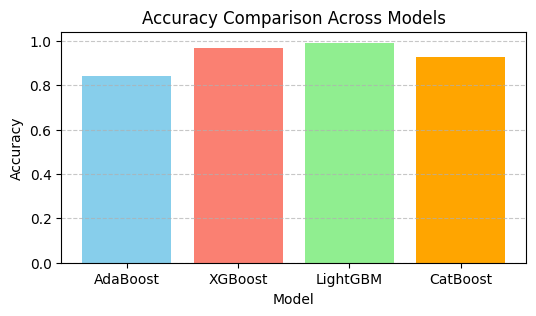

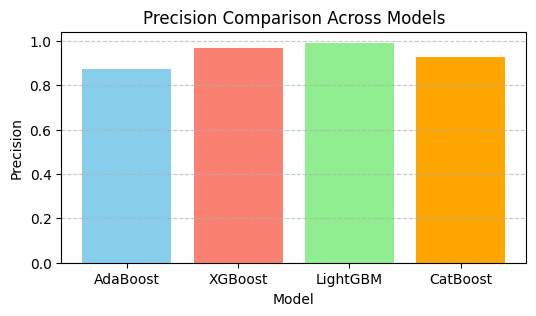

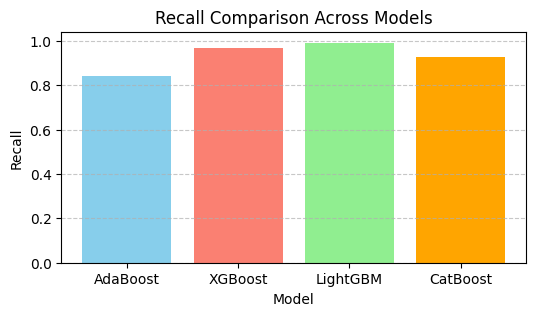

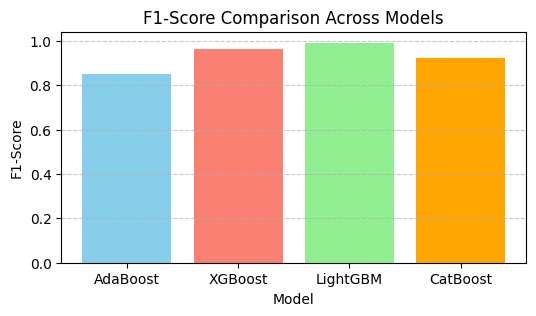

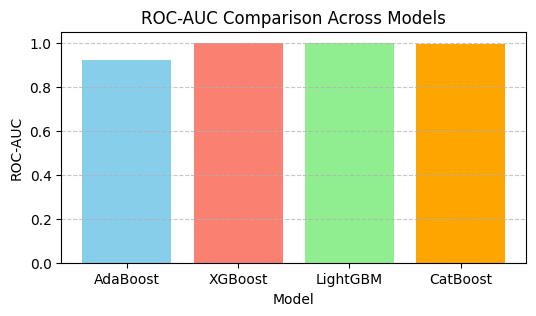

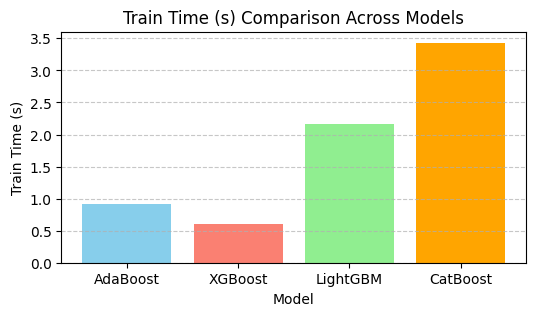

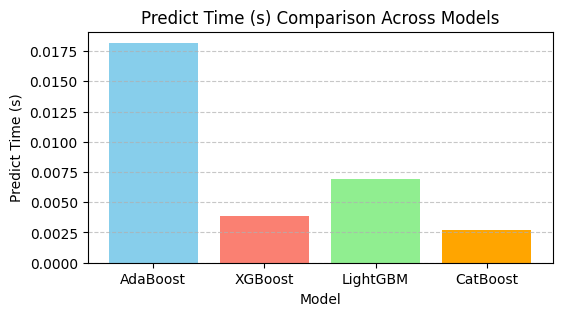

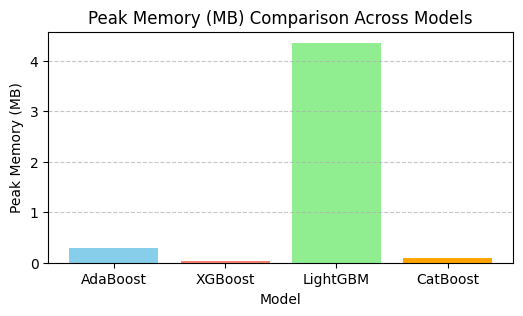

In [6]:
import matplotlib.pyplot as plt

# Metriklər
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", 
           "Train Time (s)", "Predict Time (s)", "Peak Memory (MB)"]

# Rənglər hər model üçün
colors = ['skyblue', 'salmon', 'lightgreen', 'orange']

# Hər metric üçün ayrı bar chart
for metric in metrics:
    plt.figure(figsize=(6, 3))
    plt.bar(results_df["Model"], results_df[metric], color=colors)
    plt.title(f"{metric} Comparison Across Models")
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


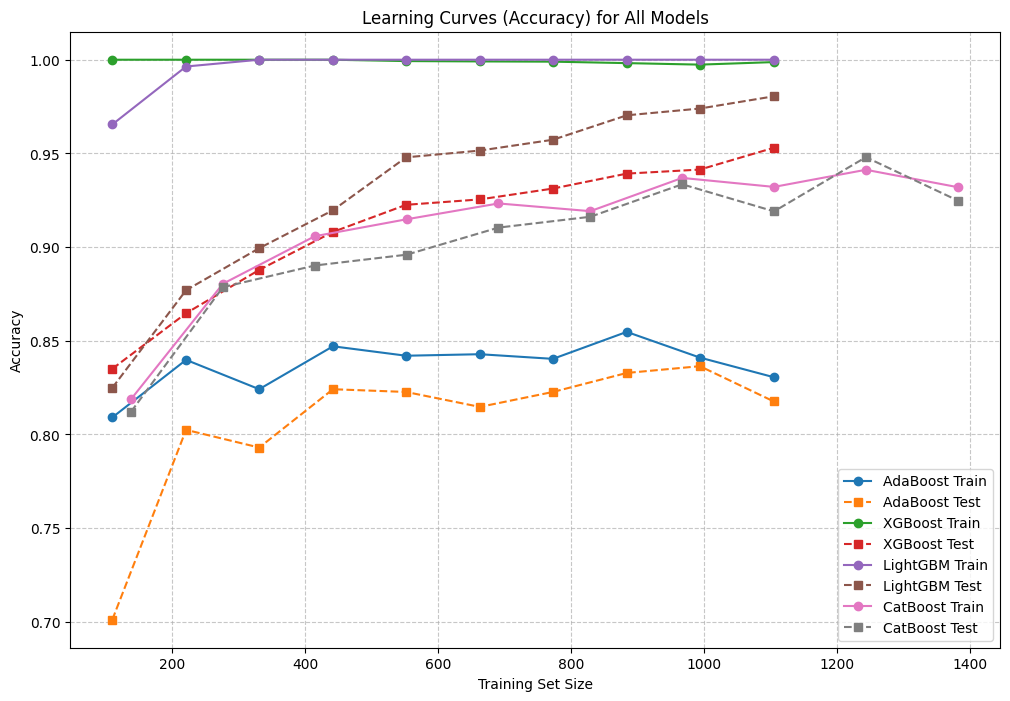

In [4]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Sklearn uyğun modellər
sklearn_models = {
    "AdaBoost": ada_clf,
    "XGBoost": xgb_clf,
    "LightGBM": lgb_clf
}

plt.figure(figsize=(12, 8))

for name, model in sklearn_models.items():
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train_enc, y_train,
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy',
        n_jobs=-1
    )
    
    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)
    
    plt.plot(train_sizes, train_mean, 'o-', label=f"{name} Train")
    plt.plot(train_sizes, test_mean, 's--', label=f"{name} Test")

# CatBoost üçün manual learning curve
train_sizes_cb = np.linspace(0.1, 1.0, 10)
train_acc_cb = []
test_acc_cb = []

for frac in train_sizes_cb:
    n = int(len(X_train_car) * frac)
    X_sub = X_train_car.iloc[:n]
    y_sub = y_train[:n]
    
    cat_model = CatBoostClassifier(
        iterations=100,
        learning_rate=0.1,
        depth=6,
        random_state=42,
        verbose=0,
        cat_features=list(range(X_train_car.shape[1]))
    )
    cat_model.fit(X_sub, y_sub)
    
    train_pred = cat_model.predict(X_sub)
    test_pred = cat_model.predict(X_test_car)
    
    train_acc_cb.append(accuracy_score(y_sub, train_pred))
    test_acc_cb.append(accuracy_score(y_test, test_pred))

plt.plot(train_sizes_cb * len(X_train_car), train_acc_cb, 'o-', label="CatBoost Train")
plt.plot(train_sizes_cb * len(X_train_car), test_acc_cb, 's--', label="CatBoost Test")

plt.title("Learning Curves (Accuracy) for All Models")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



AdaBoost FEATURE IMPORTANCE
       Feature  Importance
    safety_low    0.166229
    safety_med    0.161723
lug_boot_small    0.127301
   maint_vhigh    0.089781
  buying_vhigh    0.087948
     persons_4    0.086396
  persons_more    0.076010
    buying_low    0.071183
     maint_low    0.046656
    buying_med    0.045960
     maint_med    0.040814
   doors_5more    0.000000
  lug_boot_med    0.000000
       doors_4    0.000000
       doors_3    0.000000


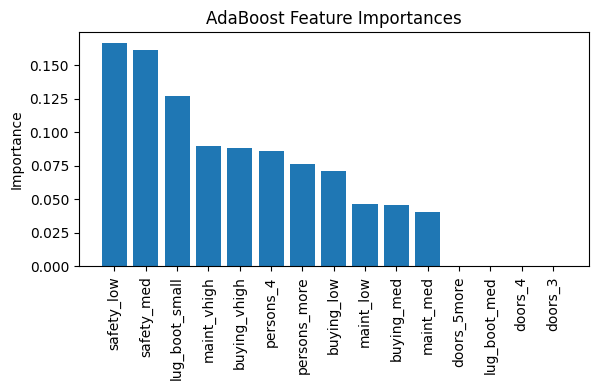


XGBoost FEATURE IMPORTANCE
       Feature  Importance
    safety_low    0.331574
  persons_more    0.183708
     persons_4    0.076229
  buying_vhigh    0.057590
   maint_vhigh    0.055892
     maint_low    0.045504
lug_boot_small    0.039937
     maint_med    0.039478
    buying_low    0.038984
    buying_med    0.037986
    safety_med    0.028346
   doors_5more    0.018597
       doors_3    0.016758
  lug_boot_med    0.016457
       doors_4    0.012959


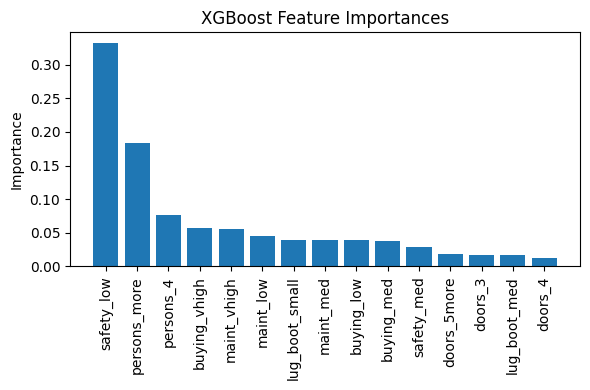


LightGBM FEATURE IMPORTANCE
       Feature  Importance
    safety_med        1178
    buying_low        1168
  persons_more        1067
lug_boot_small        1066
    buying_med         992
     maint_med         949
  lug_boot_med         938
     persons_4         896
     maint_low         883
  buying_vhigh         524
   maint_vhigh         520
       doors_4         502
       doors_3         482
   doors_5more         452
    safety_low         239


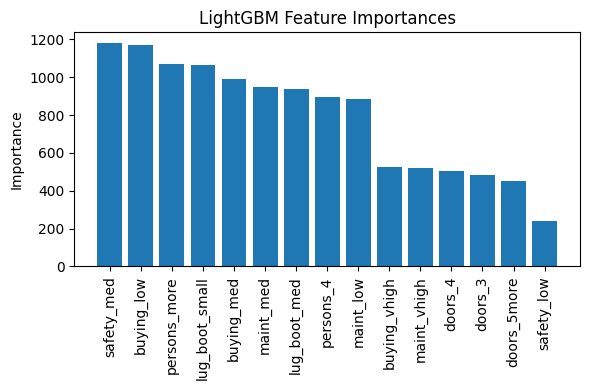


CatBoost FEATURE IMPORTANCE
 Feature  Importance
  safety   30.676423
 persons   23.605208
  buying   22.259365
   maint   13.014511
lug_boot   10.444493
   doors    0.000000


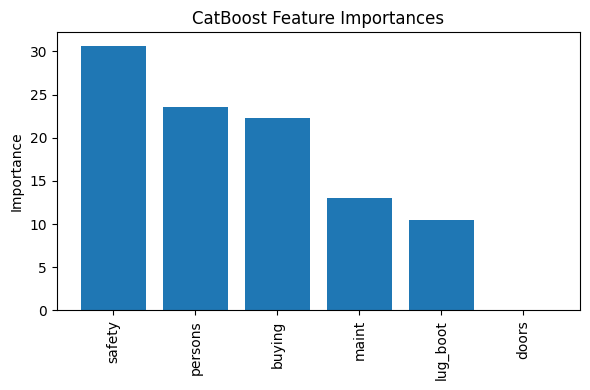

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

models = {
    "AdaBoost": ada_clf,
    "XGBoost": xgb_clf,
    "LightGBM": lgb_clf,
    "CatBoost": cat_clf
}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"{name} FEATURE IMPORTANCE")
    print(f"{'='*60}")
    
    # Feature importance və feature adları
    if name == "CatBoost":
        importances = model.get_feature_importance()
        features = X_train_car.columns
    else:
        importances = model.feature_importances_
        features = ohe.get_feature_names_out(X_train_car.columns)

    # Sıralama (böyükdən kiçiyə)
    indices = np.argsort(importances)[::-1]
    sorted_features = np.array(features)[indices]
    sorted_importances = importances[indices]

    # ====== TABLE FORMAT PRINT ======
    df_importance = pd.DataFrame({
        "Feature": sorted_features,
        "Importance": sorted_importances
    })

    print(df_importance.to_string(index=False))

    # ====== PLOT ======
    plt.figure(figsize=(6, 4))
    plt.title(f"{name} Feature Importances")
    plt.bar(range(len(sorted_features)), sorted_importances)
    plt.xticks(range(len(sorted_features)), sorted_features, rotation=90)
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()

